# Assignment 6.2 - More Trees

## Task 6.2.1 - Classification Trees

* Implement the Classification Tree Class from scratch using only `NumPy`. The splitting criterion should be Gini impurity. **(RESULT)**
* Run your implementation on the `IRIS` classification dataset. **(RESULT)**

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
class Node:
    """A simple structure to represent a node in the tree."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None, proba=None):
        # Decision parameters for an internal node
        self.feature = feature     # index of feature to split on
        self.threshold = threshold # value of the threshold
        self.left = left           # left child node
        self.right = right         # right child node

        # Prediction/Statistics for a leaf node
        self.value = value         # class label (most frequent)
        self.proba = proba         # class probabilities (for all classes)

    def is_leaf_node(self):
        """Check if the node is a leaf node."""
        return self.value is not None

class DecisionTree:
    """Base class for a decision tree."""

    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

  Custom Classification Tree on IRIS Dataset Results
Total Samples: 150
Training Accuracy: **1.0000** (100% is common for max_depth=4 on Iris)
-----------------------------------------------------

--- Decision Tree Structure (Max Depth 4) ---
If Feature[2] <= 2.450:
    Leaf → class=0 (Probas: [1. 0. 0.])
Else (> 2.450):
    If Feature[3] <= 1.750:
        If Feature[2] <= 4.950:
            If Feature[3] <= 1.650:
                Leaf → class=1 (Probas: [0. 1. 0.])
            Else (> 1.650):
                Leaf → class=2 (Probas: [0. 0. 1.])
        Else (> 4.950):
            If Feature[3] <= 1.550:
                Leaf → class=2 (Probas: [0. 0. 1.])
            Else (> 1.550):
                If Feature[0] <= 6.950:
                    Leaf → class=1 (Probas: [0. 1. 0.])
                Else (> 6.950):
                    Leaf → class=2 (Probas: [0. 0. 1.])
    Else (> 1.750):
        If Feature[2] <= 4.850:
            If Feature[0] <= 5.950:
                Leaf → class=1 (Prob

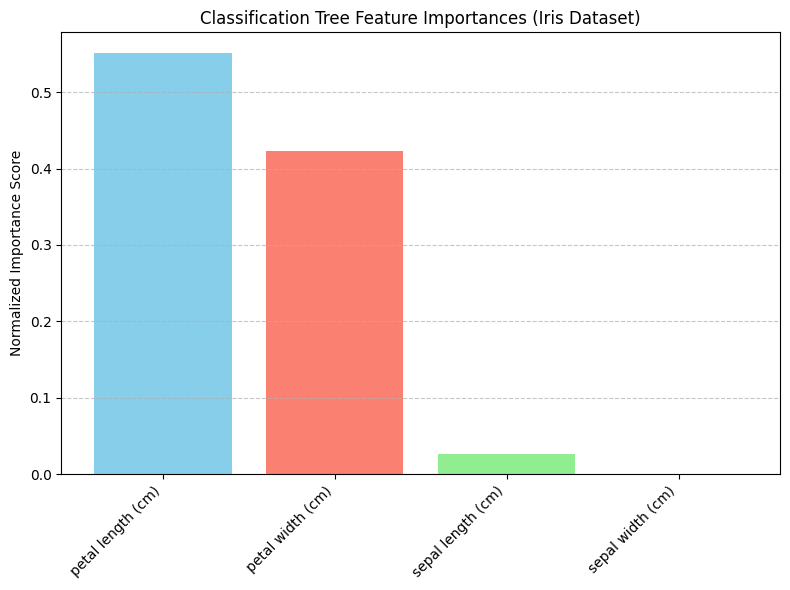

In [ ]:
class ClassificationTree(DecisionTree):
    """Classification decision tree using Gini impurity."""
    def __init__(self, max_depth=None, min_samples_split=2, max_features=None):
        super().__init__(max_depth, min_samples_split)
        self.max_features = max_features  # Store the max_features parameter
    def _gini(self, y):
        """Calculate the Gini impurity for a set of labels y."""
        if len(y) == 0:
            return 0.0

        # Count the occurrences of each class
        counts = np.bincount(y, minlength=self.n_classes)
        # Calculate probabilities
        p = counts / len(y)
        # Gini = 1 - sum(p^2)
        return 1.0 - np.sum(p**2)

    def _weighted_gini(self, yl, yr):
        """Calculate the weighted Gini impurity of a split."""
        n = len(yl) + len(yr)
        if n == 0:
            return 0.0

        weight_l = len(yl) / n
        weight_r = len(yr) / n

        return weight_l * self._gini(yl) + weight_r * self._gini(yr)

    # -----------------------------------------------------
    # THRESHOLDS = midpoints
    # -----------------------------------------------------

    def _thresholds(self, col):
        """Calculate potential split thresholds (midpoints between unique values)."""
        vals = np.unique(col)
        # Compute the average of adjacent unique values
        if len(vals) < 2:
            return np.array([])
        return (vals[:-1] + vals[1:]) / 2.0

    # -----------------------------------------------------
    # LEAF NODE CREATION
    # -----------------------------------------------------

    def _leaf(self, y):
        """Create a leaf node."""
        counts = np.bincount(y, minlength=self.n_classes)
        prob = counts / counts.sum()

        return Node(
            value=np.argmax(prob),
            proba=prob
        )

    # -----------------------------------------------------
    # BUILD TREE RECURSIVELY
    # -----------------------------------------------------

    def _build_tree(self, X, y, depth):

        num_samples, num_features = X.shape

        # --- STOPPING CRITERIA ---
        # 1. Max depth reached
        # 2. Not enough samples to split
        # 3. Node is pure (all samples are the same class)
        if self.max_features is None:
            n_subfeatures = num_features
        elif self.max_features == "sqrt":
            n_subfeatures = int(np.sqrt(num_features))
        elif isinstance(self.max_features, int):
            n_subfeatures = self.max_features
        else:
            n_subfeatures = num_features
        # Select a random subset of features to consider for splitting
        feature_subset = np.random.choice(num_features, n_subfeatures, replace=False)
        impurity_before = self._gini(y)
        best_gain = -1.0
        best_feature = None
        best_threshold = None
        best_left_indices = None
        best_right_indices = None

        # --- FIND BEST SPLIT (Iterate through all features and thresholds) ---
        for feature in range(num_features):
            thresholds = self._thresholds(X[:, feature])

            for t in thresholds:
                # Split indices based on threshold
                left_idx = X[:, feature] <= t
                right_idx = ~left_idx

                # Skip if split creates an empty child
                if left_idx.sum() == 0 or right_idx.sum() == 0:
                    continue

                # Calculate weighted Gini after split
                gini_after = self._weighted_gini(y[left_idx], y[right_idx])

                # Calculate Information Gain (Impurity Reduction)
                gain = impurity_before - gini_after

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = t
                    best_left_indices = left_idx
                    best_right_indices = right_idx

        # --- NO SPLIT FOUND (Either no gain or no valid split) ---
        if best_feature is None or best_gain <= 0:
            return self._leaf(y)

        #  ACCUMULATE FEATURE IMPORTANCE (Normalized by total samples in the original training set)
        # Importance = Information Gain * (number of samples in node)
        self.feature_importances_[best_feature] += best_gain * num_samples

        # --- RECURSE ---
        X_left, y_left = X[best_left_indices], y[best_left_indices]
        X_right, y_right = X[best_right_indices], y[best_right_indices]

        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        # Return internal node
        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_child,
            right=right_child
        )

    # -----------------------------------------------------
    # FIT MODEL
    # -----------------------------------------------------

    def fit(self, X, y):
        """Fit the decision tree to the training data."""
        self.n_classes = len(np.unique(y))
        self.n_features = X.shape[1]
        self.total_samples = X.shape[0]

        # Initialize feature importances
        self.feature_importances_ = np.zeros(self.n_features)

        self.root = self._build_tree(X, y, depth=0)

        # Normalize importances by the sum of total gain across all splits
        total_importance = self.feature_importances_.sum()
        if total_importance > 0:
            self.feature_importances_ /= total_importance

    # -----------------------------------------------------
    # PREDICT
    # -----------------------------------------------------

    def _predict_one(self, x, node):
        """Traverse the tree to get a prediction for a single sample."""
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        """Predict the class labels for samples in X."""
        # Use a list comprehension and convert to NumPy array
        return np.array([self._predict_one(x, self.root) for x in X])

    # -----------------------------------------------------
    # VISUALIZE TREE
    # -----------------------------------------------------

    def visualize(self, node=None, depth=0):
        """Prints a text representation of the tree structure."""
        if node is None:
            node = self.root

        prefix = "    " * depth
        if node.is_leaf_node():
            print(f"{prefix}Leaf → class={node.value} (Probas: {node.proba})")
        else:
            print(f"{prefix}If Feature[{node.feature}] <= {node.threshold:.3f}:")
            self.visualize(node.left, depth + 1)
            print(f"{prefix}Else (> {node.threshold:.3f}):")
            self.visualize(node.right, depth + 1)


# ------------------------------------------------------------------
# RUN CLASSIFICATION ON IRIS DATASET
# ------------------------------------------------------------------
# 1. Load Data
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 2. Initialize and Train the Tree
# A max_depth of 3-4 is usually sufficient for the Iris dataset
tree = ClassificationTree(max_depth=4, min_samples_split=2)
tree.fit(X, y)

# 3. Predict and Evaluate
predictions = tree.predict(X)
accuracy = (predictions == y).mean()

print("=====================================================")
print("  Custom Classification Tree on IRIS Dataset Results")
print("=====================================================")
print(f"Total Samples: {len(X)}")
print(f"Training Accuracy: **{accuracy:.4f}** (100% is common for max_depth=4 on Iris)")
print("-----------------------------------------------------")

# 4. Visualize Tree Structure
print("\n--- Decision Tree Structure (Max Depth 4) ---")
tree.visualize()
print("-----------------------------------------------------")

# 5. Feature Importances
print("\n--- Feature Importances (Normalized) ---")
importances = tree.feature_importances_

# Sort data for the chart (good practice)
sorted_indices = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_indices]
sorted_names = np.array(feature_names)[sorted_indices]

for name, importance in zip(sorted_names, sorted_importances):
    print(f"  {name: <15}: {importance:.4f}")


# 6. Bar Chart Visualization (Added)
plt.figure(figsize=(8, 6))
plt.bar(sorted_names, sorted_importances, color=['skyblue', 'salmon', 'lightgreen', 'gold'])
plt.title("Classification Tree Feature Importances (Iris Dataset)")
plt.ylabel("Normalized Importance Score")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('iris_feature_importances_final_barchart.png')
print("\n[Bar chart saved as iris_feature_importances_final_barchart.png]")


## Task 6.2.2 - Random Forests

* Implement Random Forests using only `NumPy`. **(RESULT)**
* Compare the results between the random forest run of your `ClassificationTree` class on the `IRIS` dataset. **(RESULT)**


===== SUMMARY COMPARISON =====
Single ClassificationTree (max_depth=3) Accuracy: 1.0000
Random Forest (n_trees=20, max_depth=3) Accuracy: 1.0000
[Bar chart saved as random_forest_feature_importances.png]


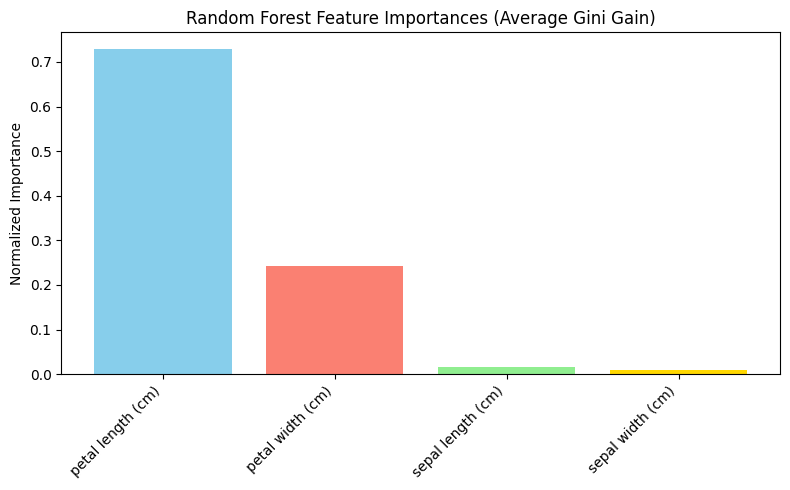

In [ ]:
class RandomForest:
    """Random Forest Classifier."""


    def __init__(self, n_trees=10, max_depth=None, min_samples_split=2,
                 max_features="sqrt", bootstrap_ratio=1.0):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.bootstrap_ratio = bootstrap_ratio
        self.trees = []
        self.feature_importances_ = None

    # ------------------------------------------
    # Fit Random Forest
    # ------------------------------------------
    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Number of random features to consider at each split (NOTE: Not used in ClassificationTree currently)
        if self.max_features == "sqrt":
            self.n_features_split = int(np.sqrt(n_features))
        elif isinstance(self.max_features, int):
            self.n_features_split = self.max_features
        else:
            self.n_features_split = n_features

        self.trees = []

        for _ in range(self.n_trees):

            # Bootstrap sampling
            m = int(self.bootstrap_ratio * n_samples)
            idx = np.random.choice(n_samples, size=m, replace=True)
            X_boot = X[idx]
            y_boot = y[idx]

            # Train a ClassificationTree
            tree = ClassificationTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )

            # Fit on bootstrapped dataset
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)

        # ------------------------------------------
        # Feature importance = average of tree importances
        # ------------------------------------------
        all_importances = np.array([t.feature_importances_ for t in self.trees])
        self.feature_importances_ = np.mean(all_importances, axis=0)

    # ------------------------------------------
    # Predict (majority vote)
    # ------------------------------------------
    def predict(self, X):
        tree_preds = np.array([t.predict(X) for t in self.trees])
        final = []
        for i in range(X.shape[0]):
            votes = np.bincount(tree_preds[:, i])
            final.append(np.argmax(votes))
        return np.array(final)

    # ------------------------------------------
    # Visualize first tree
    # ------------------------------------------
    def visualize(self):
        print("\nRandom Forest Visualization (showing first tree):")
        self.trees[0].visualize()

    # ------------------------------------------
    # Bar chart
    # ------------------------------------------
    def plot_feature_importances(self, feature_names):

        # Sort features for better plotting
        sorted_indices = np.argsort(self.feature_importances_)[::-1]
        sorted_importances = self.feature_importances_[sorted_indices]
        sorted_names = np.array(feature_names)[sorted_indices]

        plt.figure(figsize=(8,5))
        plt.bar(sorted_names, sorted_importances, color=['skyblue', 'salmon', 'lightgreen', 'gold'])
        plt.xticks(rotation=45, ha='right')
        plt.title("Random Forest Feature Importances (Average Gini Gain)")
        plt.ylabel("Normalized Importance")
        plt.tight_layout()
        plt.savefig('random_forest_feature_importances.png')
        print("[Bar chart saved as random_forest_feature_importances.png]")


# ------------------------------------------------------------------
# EXECUTION AND COMPARISON
# ------------------------------------------------------------------

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

# --- Train SINGLE TREE ---
tree = ClassificationTree(max_depth=3)
tree.fit(X, y)
pred_tree = tree.predict(X)
acc_tree = (pred_tree == y).mean()

# --- Train RANDOM FOREST ---
forest = RandomForest(n_trees=20, max_depth=3)
forest.fit(X, y)
preds_forest = forest.predict(X)
acc_forest = (preds_forest == y).mean()

print("\n===== SUMMARY COMPARISON =====")
print(f"Single ClassificationTree (max_depth=3) Accuracy: {acc_tree:.4f}")
print(f"Random Forest (n_trees=20, max_depth=3) Accuracy: {acc_forest:.4f}")

forest.plot_feature_importances(feature_names)

## Task 6.2.3 - Extra Trees

* Implement Extra Trees using only `NumPy`. **(RESULT)**
* Compare the results between the `Random Forest` and an `Extra Trees` ensemble implementation on the `IRIS` dataset. **(RESULT)**

In [ ]:
class ExtraTree(DecisionTree):
    """Extremely Randomized Tree - uses random thresholds instead of optimal ones."""

    def __init__(self, max_depth=None, min_samples_split=2, max_features="sqrt"):
        super().__init__(max_depth, min_samples_split)
        self.max_features = max_features


    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        self.n_features = X.shape[1]
        self.feature_importances_ = np.zeros(self.n_features)
        self.root = self._build_tree(X, y, depth=0)
        total_importance = self.feature_importances_.sum()
        if total_importance > 0:
            self.feature_importances_ /= total_importance


    def _gini(self, y):
        if len(y) == 0: return 0.0
        counts = np.bincount(y, minlength=self.n_classes)
        p = counts / len(y)
        return 1.0 - np.sum(p**2)

    def _weighted_gini(self, yl, yr):
        n = len(yl) + len(yr)
        if n == 0: return 0.0
        weight_l = len(yl) / n
        weight_r = len(yr) / n
        return weight_l * self._gini(yl) + weight_r * self._gini(yr)

    def _leaf(self, y):
        counts = np.bincount(y, minlength=self.n_classes)
        prob = counts / counts.sum()
        return Node(value=np.argmax(prob), proba=prob)

    # FIX 4: Including the predict method which was also likely inherited/missing
    def _predict_one(self, x, node):
        if node.is_leaf_node(): return node.value
        if x[node.feature] <= node.threshold: return self._predict_one(x, node.left)
        else: return self._predict_one(x, node.right)
    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    # The provided _build_tree method
    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape

        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_split or \
           len(np.unique(y)) == 1:
            return self._leaf(y)

        # 1. Feature Subsetting
        n_subfeatures = int(np.sqrt(num_features)) if self.max_features == "sqrt" else num_features
        feature_subset = np.random.choice(num_features, n_subfeatures, replace=False)

        impurity_before = self._gini(y)
        best_gain = -1.0
        best_feature = None
        best_threshold = None
        best_left_indices = None
        best_right_indices = None

        # 2. Random Threshold Search (The key ET difference)
        for feature in feature_subset:
            col = X[:, feature]
            min_val, max_val = col.min(), col.max()

            if min_val < max_val:
                t = np.random.uniform(min_val, max_val)
            else:
                continue

            left_idx = col <= t
            right_idx = ~left_idx

            if left_idx.sum() == 0 or right_idx.sum() == 0:
                continue

            gini_after = self._weighted_gini(y[left_idx], y[right_idx])
            gain = impurity_before - gini_after

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = t
                best_left_indices = left_idx
                best_right_indices = right_idx

        if best_feature is None or best_gain <= 0:
            return self._leaf(y)

        self.feature_importances_[best_feature] += best_gain * num_samples

        X_left, y_left = X[best_left_indices], y[best_left_indices]
        X_right, y_right = X[best_right_indices], y[best_right_indices]

        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)


In [ ]:
class ExtraTrees:
    """Extremely Randomized Trees ensemble."""

    def __init__(self, n_trees=20, max_depth=None, max_features="sqrt"):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []
        self.feature_importances_ = None

    def fit(self, X, y):
        n_samples = len(X)
        self.n_features = X.shape[1]
        self.trees = []

        for _ in range(self.n_trees):
            # No bootstrapping (replace=False for the full data set, or simply use X, y)
            # We use the full set X, y (no replacement) for pure ET implementation.
            X_tree, y_tree = X, y

            tree = ExtraTree(max_depth=self.max_depth, max_features=self.max_features)
            tree.fit(X_tree, y_tree)
            self.trees.append(tree)

        # Feature importance = average of tree importances
        all_importances = np.array([t.feature_importances_ for t in self.trees])
        self.feature_importances_ = np.mean(all_importances, axis=0)

    def predict(self, X):
        tree_preds = np.array([t.predict(X) for t in self.trees])
        final = []
        for i in range(X.shape[0]):
            votes = np.bincount(tree_preds[:, i])
            final.append(np.argmax(votes))
        return np.array(final)





===== ENSEMBLE COMPARISON (NumPy Implementation) =====
Random Forest (RF) Training Accuracy: 1.0000
Extra Trees (ET) Training Accuracy:   0.9800
--------------------------------------------------
[Comparison bar chart saved as rf_et_comparison_importances.png]


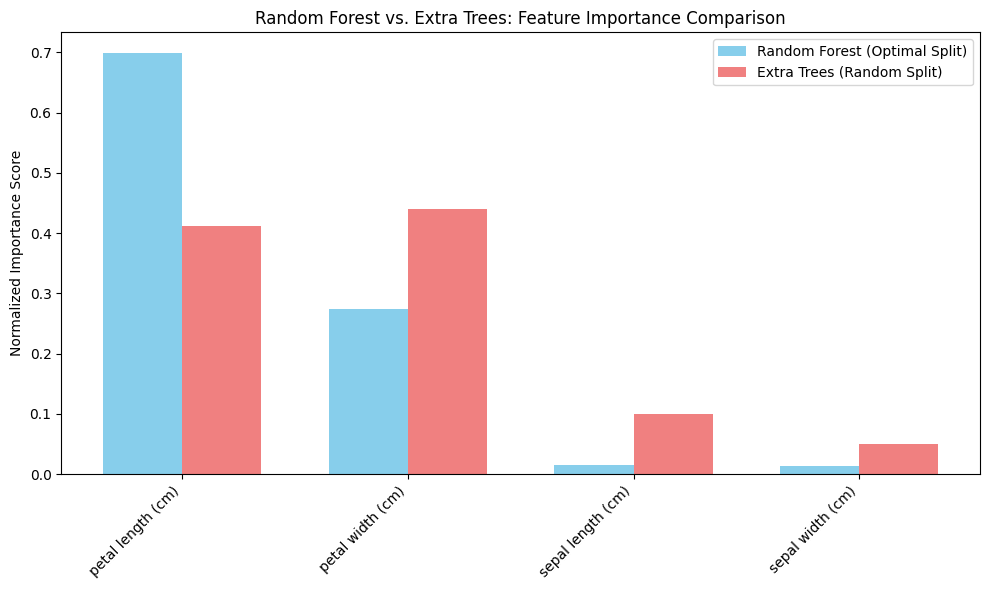

In [ ]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names

# --- 1. Train Random Forest (RF) ---
rf = RandomForest(n_trees=20, max_depth=5)
rf.fit(X, y)
rf_acc = (rf.predict(X) == y).mean()

# --- 2. Train Extra Trees (ET) ---
et = ExtraTrees(n_trees=20, max_depth=5)
et.fit(X, y)
et_acc = (et.predict(X) == y).mean()

print("\n===== ENSEMBLE COMPARISON (NumPy Implementation) =====")
print(f"Random Forest (RF) Training Accuracy: {rf_acc:.4f}")
print(f"Extra Trees (ET) Training Accuracy:   {et_acc:.4f}")
print("-" * 50)

# 3. Visualize Feature Importances

rf_imp = rf.feature_importances_
et_imp = et.feature_importances_

# Sort features by importance
rf_idx = np.argsort(rf_imp)[::-1]
et_idx = np.argsort(et_imp)[::-1]
sorted_feature_names = np.array(feature_names)[rf_idx]

# Create comparison bar chart
plt.figure(figsize=(10, 6))
width = 0.35
x = np.arange(len(feature_names))

plt.bar(x - width/2, rf_imp[rf_idx], width, label='Random Forest (Optimal Split)', color='skyblue')
# Note: Since the features are sorted by RF importance, we map ET importance to RF's order for comparison
et_ordered_imp = et_imp[rf_idx]
plt.bar(x + width/2, et_ordered_imp, width, label='Extra Trees (Random Split)', color='lightcoral')

plt.xticks(x, sorted_feature_names, rotation=45, ha='right')
plt.title('Random Forest vs. Extra Trees: Feature Importance Comparison')
plt.ylabel('Normalized Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig('rf_et_comparison_importances.png')
print("[Comparison bar chart saved as rf_et_comparison_importances.png]")